# Deutsche Bahn Train Delay Analysis

## Final Data Visualization Project

### Project purpose

This project investigates when, where and which types of trains experienced
the most delays across major German railway stations in the available dataset.

### Dataset

- Dataset: Deutsche Bahn trains and delays at main stations
- Unit of observation: One train service recorded at one main station
- Geographic coverage: 20 German main railway stations
- Main variables: station, date, scheduled time, expected time, train model,
  route, platform and delay status
- Original source: Add the website link where the CSV was downloaded

In [31]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go


In [32]:
raw_folder = Path("data/raw")

list(raw_folder.iterdir())

[WindowsPath('data/raw/.ipynb_checkpoints'),
 WindowsPath('data/raw/trains_db_hbfs.csv')]

In [33]:
DATA_PATH = Path("data/raw/trains_db_hbfs.csv")

df_raw = pd.read_csv(DATA_PATH)

df = df_raw.copy()

df.head()


,date,Hbf,scheduled_time,expected_time,train_model,route,platform,real_time_due_to_delay,has_delay
0,2024-09-01,Köln Hbf,13:00,13:00,RE 8(10819),"Rommerskirchen, 13:00",3,13:00,0
1,2024-09-01,Hannover Hbf,13:00,13:00,S 2,"Nienburg(Weser), 13:00",1,13:00,0
2,2024-09-01,Münster(Westf)Hbf,13:00,13:00,RB 89(90018),"Paderborn Hbf, 13:00",3,13:00,0
3,2024-09-01,Hamburg Hbf,13:01,13:01,S 5,"Hamburg Elbgaustraße, 13:01",4Hamburg Hbf (S-Bahn),13:01,0
4,2024-09-01,Frankfurt(Main)Hbf,13:01,13:01,S 4,"Kronberg(Taunus), 13:01",101Frankfurt Hbf (tief),13:01,0


In [34]:
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 77,146
Number of columns: 9


In [35]:
df.columns.tolist()


['date',
 'Hbf',
 'scheduled_time',
 'expected_time',
 'train_model',
 'route',
 'platform',
 'real_time_due_to_delay',
 'has_delay']

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 77146 entries, 0 to 77145
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   date                    77146 non-null  str  
 1   Hbf                     77146 non-null  str  
 2   scheduled_time          77146 non-null  str  
 3   expected_time           77146 non-null  str  
 4   train_model             77146 non-null  str  
 5   route                   77146 non-null  str  
 6   platform                77146 non-null  str  
 7   real_time_due_to_delay  63116 non-null  str  
 8   has_delay               77146 non-null  int64
dtypes: int64(1), str(8)
memory usage: 11.9 MB


In [37]:
missing_summary = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2)
})

missing_summary = missing_summary.sort_values(
    "missing_values",
    ascending=False
)

display(missing_summary)

,missing_values,missing_percentage
real_time_due_to_delay,14030,18.19
date,0,0.00
Hbf,0,0.00
expected_time,0,0.00
scheduled_time,0,0.00
train_model,0,0.00
route,0,0.00
platform,0,0.00
has_delay,0,0.00


In [38]:
#First we need to inspect whether they are genuine duplicated records or repeated services appearing at different stations.

duplicate_count = df.duplicated().sum()

print(f"Exact duplicate rows: {duplicate_count:,}")

Exact duplicate rows: 670


In [39]:
station_summary = (
    df["Hbf"]
    .value_counts()
    .rename_axis("station")
    .reset_index(name="records")
)

display(station_summary)

,station,records
0,Münich Hbf,8824
1,Frankfurt(Main)Hbf,8126
2,Hamburg Hbf,7979
3,Stuttgart Hbf,5863
4,Berlin Hbf,5692
5,Düsseldorf Hbf,5357
6,Köln Hbf,4796
7,Leipzig Hbf,4213
8,Hannover Hbf,3975
9,Nürnberg Hbf,3941


In [40]:
delay_summary = (
    df["has_delay"]
    .value_counts(dropna=False)
    .rename_axis("has_delay")
    .reset_index(name="records")
)

delay_summary["percentage"] = (
    delay_summary["records"] / len(df) * 100
).round(2)

display(delay_summary)

,has_delay,records,percentage
0,0,42892,55.6
1,1,34254,44.4


In [41]:
df.sample(10, random_state=42)

,date,Hbf,scheduled_time,expected_time,train_model,route,platform,real_time_due_to_delay,has_delay
48719,2024-07-23,Hamburg Hbf,22:53,22:53,S 2,Hamburg-Altona(S),4Hamburg Hbf (S-Bahn),NaN,0
28905,2024-07-25,Frankfurt(Main)Hbf,08:44,08:44,ICE 527,"Dortmund Hbf, 08:54",8,"08:54,Grund: Polizeieinsatz",1
20294,2024-07-20,Berlin Hbf,09:02,09:02,Bus S7,Berlin Alexanderplatz,-Berlin Hbf (Invalidenstraße),NaN,0
55814,2024-07-24,Nürnberg Hbf,10:03,10:03,S 3,"Altdorf(b Nürnberg), 10:03",2,10:03,0
19619,2024-07-22,Leipzig Hbf,08:25,08:25,Bus S3,"Schkeuditz, 08:35",-Leipzig Hbf Ostseite,08:35,1
12362,2024-09-02,Bielefeld Hbf,13:28,13:28,WFB RE70(95828),"Braunschweig Hbf, 13:35",3 C-E,13:35,1
51218,2024-07-23,Leipzig Hbf,13:16,13:16,S 2,"Leipzig-Stötteritz, 13:16",2Leipzig Hbf (tief),13:16,0
48382,2024-07-21,Hamburg Hbf,10:43,10:43,S 2,Hamburg-Altona(S),4Hamburg Hbf (S-Bahn),NaN,0
66006,2024-07-25,Köln Hbf,10:56,11:00,S 6,"Köln-Worringen, Köln Hbf: Störung. (Quelle: zu...",10 A-B,"11:00,Grund: Verspätung aus vorheriger Fahrt",1
32231,2024-07-21,Hannover Hbf,11:20,11:20,ICE 787,"Hamburg Hbf, 11:26",7,"11:26,Grund: Reparatur an einem Signal",1


In [42]:
df.head()

,date,Hbf,scheduled_time,expected_time,train_model,route,platform,real_time_due_to_delay,has_delay
0,2024-09-01,Köln Hbf,13:00,13:00,RE 8(10819),"Rommerskirchen, 13:00",3,13:00,0
1,2024-09-01,Hannover Hbf,13:00,13:00,S 2,"Nienburg(Weser), 13:00",1,13:00,0
2,2024-09-01,Münster(Westf)Hbf,13:00,13:00,RB 89(90018),"Paderborn Hbf, 13:00",3,13:00,0
3,2024-09-01,Hamburg Hbf,13:01,13:01,S 5,"Hamburg Elbgaustraße, 13:01",4Hamburg Hbf (S-Bahn),13:01,0
4,2024-09-01,Frankfurt(Main)Hbf,13:01,13:01,S 4,"Kronberg(Taunus), 13:01",101Frankfurt Hbf (tief),13:01,0


# 2. Data Preparation

Before answering the analytical questions, the dataset is cleaned and new
variables are created.

The preparation includes:

- removing exact duplicate records;
- standardising station names;
- converting dates and times;
- calculating actual delay duration;
- extracting the scheduled hour and day type;
- grouping services into broad train categories;
- identifying recorded platform changes;
- extracting recorded disruption reasons.

Delay rate is calculated from the `has_delay` field.

Actual delay duration is calculated only where a usable real-time value is
available in `real_time_due_to_delay`.

In [43]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go


# Plotly colours selected from a colour-vision-deficiency-safe palette
CVD_BLUE = "#0072B2"
CVD_ORANGE = "#E69F00"
CVD_GREEN = "#009E73"
CVD_RED = "#D55E00"
CVD_PURPLE = "#CC79A7"
CONTEXT_GREY = "#BDBDBD"


# Load the original CSV
DATA_PATH = Path("data/raw/trains_db_hbfs.csv")

df_raw = pd.read_csv(DATA_PATH)

# Create a working copy so that the original data remains unchanged
clean = df_raw.copy()


# Record the original size
original_rows = len(clean)
duplicate_rows = clean.duplicated().sum()


# Remove exact duplicate records
clean = clean.drop_duplicates().copy()


# Rename Hbf to a simpler English column name
clean = clean.rename(columns={"Hbf": "station"})


# Correct one inconsistent station spelling
clean["station"] = clean["station"].replace({
    "Münich Hbf": "München Hbf"
})


# Convert date into a proper datetime variable
clean["date"] = pd.to_datetime(
    clean["date"],
    errors="coerce"
)


# Combine date and scheduled time
clean["scheduled_datetime"] = pd.to_datetime(
    clean["date"].dt.strftime("%Y-%m-%d")
    + " "
    + clean["scheduled_time"],
    errors="coerce"
)


# Combine date and expected time
clean["expected_datetime"] = pd.to_datetime(
    clean["date"].dt.strftime("%Y-%m-%d")
    + " "
    + clean["expected_time"],
    errors="coerce"
)


# Calculate the difference between expected and scheduled time
clean["expected_delay_minutes"] = (
    clean["expected_datetime"]
    - clean["scheduled_datetime"]
).dt.total_seconds() / 60


# Correct records that pass midnight
clean.loc[
    clean["expected_delay_minutes"] < -720,
    "expected_delay_minutes"
] += 1440


# Extract the first HH:MM time from the real-time information
clean["actual_time"] = (
    clean["real_time_due_to_delay"]
    .astype("string")
    .str.extract(r"(\d{2}:\d{2})", expand=False)
)


# Create an actual datetime
clean["actual_datetime"] = pd.to_datetime(
    clean["date"].dt.strftime("%Y-%m-%d")
    + " "
    + clean["actual_time"],
    errors="coerce"
)


# Calculate actual delay duration
clean["actual_delay_minutes"] = (
    clean["actual_datetime"]
    - clean["scheduled_datetime"]
).dt.total_seconds() / 60


# Correct delays that cross midnight
clean.loc[
    clean["actual_delay_minutes"] < -720,
    "actual_delay_minutes"
] += 1440


# Create time variables
clean["hour"] = clean["scheduled_datetime"].dt.hour
clean["weekday"] = clean["date"].dt.day_name()

clean["day_type"] = np.where(
    clean["weekday"].isin(["Saturday", "Sunday"]),
    "Weekend",
    "Weekday"
)


# Extract the first service code from train_model
clean["train_code"] = (
    clean["train_model"]
    .astype("string")
    .str.strip()
    .str.split()
    .str[0]
    .str.upper()
)


# Function used to place services into broad groups
def classify_train(code):
    if pd.isna(code):
        return "Other"

    if code.startswith("BUS") or code == "RRB":
        return "Bus / replacement"

    if code == "S":
        return "S-Bahn"

    if code.startswith("ICE") or code in {
        "IC", "EC", "ECE", "EN", "NJ",
        "RJ", "RJX", "TGV", "FLX", "EST", "D"
    }:
        return "Long-distance"

    if (
        code.startswith("RE")
        or code.startswith("RB")
        or code in {
            "IRE", "MEX", "NWB", "VIA", "BRB",
            "ME", "WFB", "HLB", "ALX", "TL",
            "NBE", "ENO", "ERX", "TLX", "WB"
        }
    ):
        return "Regional"

    return "Other"


clean["train_group"] = clean["train_code"].map(classify_train)


# Identify records mentioning a platform change
clean["platform_change"] = (
    clean["real_time_due_to_delay"]
    .astype("string")
    .str.contains(
        "Gleiswechsel",
        case=False,
        na=False
    )
)


# Extract the reason appearing after "Grund:"
clean["delay_reason"] = (
    clean["real_time_due_to_delay"]
    .astype("string")
    .str.extract(
        r"Grund:\s*([^,]+)",
        expand=False
    )
    .str.strip()
)


# Make sure the delay flag is numeric
clean["has_delay"] = clean["has_delay"].astype(int)


print(f"Original records: {original_rows:,}")
print(f"Exact duplicates removed: {duplicate_rows:,}")
print(f"Cleaned records: {len(clean):,}")
print(f"Stations: {clean['station'].nunique()}")
print(f"Sampled dates: {clean['date'].nunique()}")

Original records: 77,146
Exact duplicates removed: 670
Cleaned records: 76,476
Stations: 20
Sampled dates: 8


## 2.1 Data-preparation check

The following checks confirm that the new variables were created correctly
before the analytical questions are answered.

In [44]:
columns_to_check = [
    "date",
    "station",
    "scheduled_time",
    "actual_time",
    "hour",
    "weekday",
    "day_type",
    "train_model",
    "train_code",
    "train_group",
    "has_delay",
    "actual_delay_minutes",
    "platform_change",
    "delay_reason"
]

clean[columns_to_check].sample(
    10,
    random_state=42
)

,date,station,scheduled_time,actual_time,hour,weekday,day_type,train_model,train_code,train_group,has_delay,actual_delay_minutes,platform_change,delay_reason
27803,2024-07-20,Frankfurt(Main)Hbf,14:08,14:28,14,Saturday,Weekend,ICE 74,ICE,Long-distance,1,20.0,False,Verspätetes Personal aus vorheriger Fahrt
127,2024-09-01,Münster(Westf)Hbf,13:24,13:24,13,Sunday,Weekend,RB 65(52327),RB,Regional,0,0.0,False,<NA>
11022,2024-09-02,Frankfurt(Main)Hbf,10:09,10:11,10,Monday,Weekday,HLB RB41(15007),HLB,Regional,1,2.0,False,<NA>
6680,2024-09-02,Köln Hbf,05:26,05:26,5,Monday,Weekday,RB 38(10252),RB,Regional,0,0.0,False,<NA>
68313,2024-07-23,München Hbf,14:13,14:17,14,Tuesday,Weekday,S 8,S,S-Bahn,1,4.0,False,<NA>
16854,2024-09-02,München Hbf,09:18,09:25,9,Monday,Weekday,ICE 991,ICE,Long-distance,1,7.0,False,<NA>
73311,2024-07-24,Köln Hbf,00:39,00:40,0,Wednesday,Weekday,S 19,S,S-Bahn,1,1.0,False,<NA>
76333,2024-07-23,München Hbf,22:41,22:45,22,Tuesday,Weekday,RE 3(4087),RE,Regional,1,4.0,False,<NA>
22097,2024-07-21,Dortmund Hbf,19:01,<NA>,19,Sunday,Weekend,Bus RB43,BUS,Bus / replacement,0,NaN,False,<NA>
74261,2024-07-22,Düsseldorf Hbf,10:45,10:54,10,Monday,Weekday,S 28,S,S-Bahn,1,9.0,False,<NA>


In [45]:
PROCESSED_PATH = Path(
    "data/processed/trains_db_hbfs_cleaned.csv"
)

clean.to_csv(
    PROCESSED_PATH,
    index=False
)

print(f"Cleaned dataset saved to: {PROCESSED_PATH}")

Cleaned dataset saved to: data\processed\trains_db_hbfs_cleaned.csv


# 3. Analytical Questions and Explanatory Visualisations

The following ten questions examine relationships between station, service
volume, train category, scheduled time, sampled date, actual delay duration,
platform changes and recorded disruption reasons.

Basic one-variable counts are treated only as preliminary exploration and are
not included among the ten analytical questions.

## Question 1 — Which stations recorded the highest delay rates, and how did this relate to their service volume?

### Why this matters

A station with many delayed trains may simply have more recorded services.
Delay rate therefore provides a fairer comparison than the total number of
delayed records alone.

### Method

For every station, the total number of services and percentage marked as
delayed are calculated. A bubble chart compares service volume with delay rate.

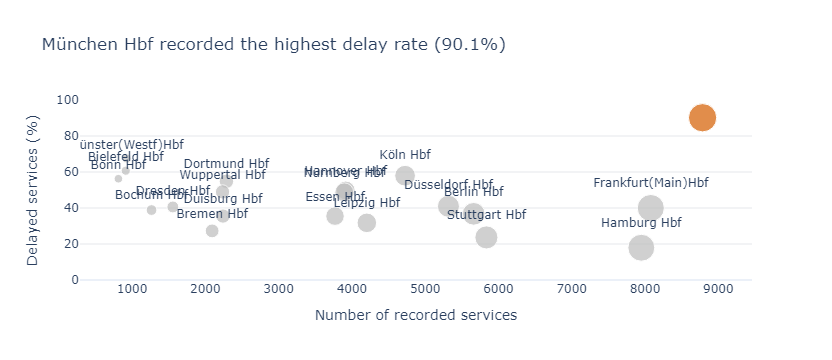

In [46]:
station_stats = (
    clean.groupby(
        "station",
        as_index=False
    )
    .agg(
        total_services=("has_delay", "size"),
        delayed_services=("has_delay", "sum"),
        delay_rate=("has_delay", "mean")
    )
)

station_stats["delay_rate_pct"] = (
    station_stats["delay_rate"] * 100
)


top_station = station_stats.loc[
    station_stats["delay_rate_pct"].idxmax(),
    "station"
]

top_rate = station_stats["delay_rate_pct"].max()


station_stats["highlight"] = np.where(
    station_stats["station"].eq(top_station),
    "Highest delay rate",
    "Other stations"
)


fig = px.scatter(
    station_stats,
    x="total_services",
    y="delay_rate_pct",
    size="total_services",
    text="station",
    color="highlight",
    color_discrete_map={
        "Other stations": CONTEXT_GREY,
        "Highest delay rate": CVD_RED
    },
    hover_data={
        "delayed_services": ":,",
        "delay_rate_pct": ":.1f",
        "total_services": ":,",
        "highlight": False
    },
    title=(
        f"{top_station} recorded the highest delay rate "
        f"({top_rate:.1f}%)"
    )
)

fig.update_traces(
    textposition="top center"
)

fig.update_layout(
    template="plotly_white",
    showlegend=False
)

fig.update_xaxes(
    title="Number of recorded services",
    showgrid=False
)

fig.update_yaxes(
    title="Delayed services (%)",
    range=[0, 100],
    gridcolor="#E5E7EB"
)

fig.show()

### Answer

München Hbf had the highest recorded delay rate at approximately **90.1%**,
despite also having one of the largest service volumes in the dataset.
Münster (Westf) Hbf and Bielefeld Hbf followed at approximately **67.6%** and
**60.7%** respectively.

Hamburg Hbf recorded a substantially lower rate of approximately **17.9%**,
even though it had a high number of recorded services. This shows that service
volume alone does not explain the large variation in station delay rates.

The unusually high result for München should be interpreted carefully because
the dataset represents only eight sampled dates.

## Question 2 — Which broad train-service groups had the highest delay rates?

### Why this matters

Comparing train categories helps determine whether delay risk differs between
long-distance, regional, suburban and replacement services.

### Method

Train models are grouped into long-distance, regional, S-Bahn,
bus/replacement and other services. The proportion marked as delayed is then
compared across groups.

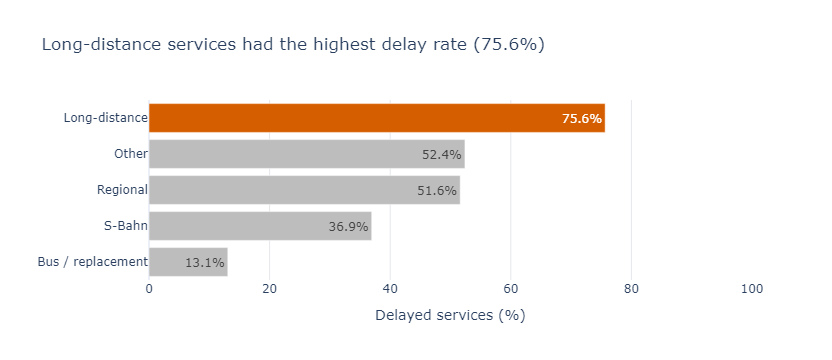

In [47]:
group_stats = (
    clean.groupby(
        "train_group",
        as_index=False
    )
    .agg(
        total_services=("has_delay", "size"),
        delayed_services=("has_delay", "sum"),
        delay_rate=("has_delay", "mean")
    )
)

group_stats["delay_rate_pct"] = (
    group_stats["delay_rate"] * 100
)

group_stats = group_stats.sort_values(
    "delay_rate_pct"
)


top_group = group_stats.iloc[-1]["train_group"]
top_group_rate = group_stats.iloc[-1]["delay_rate_pct"]


group_stats["highlight"] = np.where(
    group_stats["train_group"].eq(top_group),
    "Highest",
    "Other"
)


fig = px.bar(
    group_stats,
    x="delay_rate_pct",
    y="train_group",
    orientation="h",
    text=group_stats["delay_rate_pct"].map(
        lambda value: f"{value:.1f}%"
    ),
    color="highlight",
    color_discrete_map={
        "Other": CONTEXT_GREY,
        "Highest": CVD_RED
    },
    hover_data={
        "total_services": ":,",
        "delayed_services": ":,",
        "highlight": False
    },
    title=(
        f"{top_group} services had the highest delay rate "
        f"({top_group_rate:.1f}%)"
    )
)

fig.update_layout(
    template="plotly_white",
    showlegend=False
)

fig.update_xaxes(
    title="Delayed services (%)",
    range=[0, 100],
    gridcolor="#E5E7EB"
)

fig.update_yaxes(
    title=""
)

fig.show()

### Answer

Long-distance services had the highest delay rate at approximately **75.6%**.
Regional services followed at approximately **51.6%**, while S-Bahn services
recorded approximately **36.9%**.

Bus and replacement services had the lowest rate at approximately **13.1%**.
The result suggests that long-distance services were substantially more likely
to be marked as delayed than the other major categories in this sample.

## Question 3 — How did delay rates change by scheduled hour for different train groups?

### Why this matters

Overall group averages can hide changes across the day. Examining scheduled
hour reveals whether particular train groups become more vulnerable during
specific periods.

### Method

Services are grouped by scheduled departure hour and train group. The delay
rate is calculated separately for each combination.

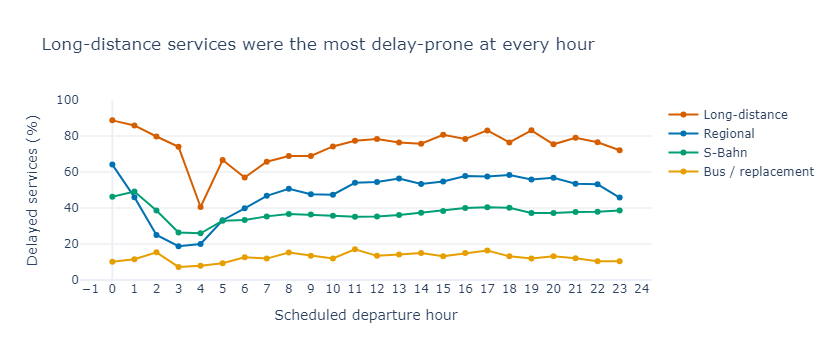

In [48]:
hourly_stats = (
    clean[
        clean["train_group"] != "Other"
    ]
    .groupby(
        ["hour", "train_group"],
        as_index=False
    )
    .agg(
        total_services=("has_delay", "size"),
        delay_rate=("has_delay", "mean")
    )
)

hourly_stats["delay_rate_pct"] = (
    hourly_stats["delay_rate"] * 100
)


group_order = [
    "Long-distance",
    "Regional",
    "S-Bahn",
    "Bus / replacement"
]


group_palette = {
    "Long-distance": CVD_RED,
    "Regional": CVD_BLUE,
    "S-Bahn": CVD_GREEN,
    "Bus / replacement": CVD_ORANGE
}


fig = px.line(
    hourly_stats,
    x="hour",
    y="delay_rate_pct",
    color="train_group",
    markers=True,
    category_orders={
        "train_group": group_order
    },
    color_discrete_map=group_palette,
    hover_data={
        "total_services": ":,",
        "delay_rate_pct": ":.1f"
    },
    title=(
        "Long-distance services were the most "
        "delay-prone at every hour"
    )
)

fig.update_layout(
    template="plotly_white",
    legend_title_text=""
)

fig.update_xaxes(
    title="Scheduled departure hour",
    dtick=1,
    showgrid=False
)

fig.update_yaxes(
    title="Delayed services (%)",
    range=[0, 100],
    gridcolor="#E5E7EB"
)

fig.show()

### Answer

Long-distance services had the highest delay rate during every scheduled hour.
Their delay rate reached approximately **88.7% around midnight**, while even
their lowest hourly result remained above many other service categories.

Regional and S-Bahn rates generally increased during the afternoon and evening.
The result suggests that the difference between service types was more
important than a single common peak-hour pattern.

## Question 4 — Which station and train-group combinations were the most delay-prone?

### Why this matters

A train category may perform differently at different stations. Examining both
dimensions can identify combinations that would be hidden by national group
averages.

### Method

Delay rates are calculated for every station and train-group combination.
Combinations with fewer than 100 records are excluded to avoid unstable
percentages.

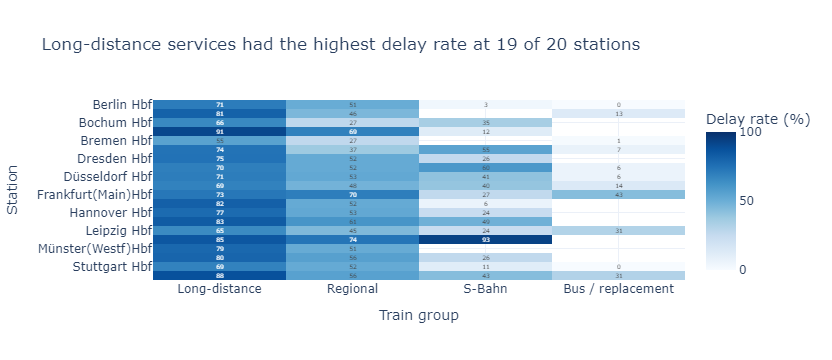

In [49]:
station_group_stats = (
    clean[
        clean["train_group"] != "Other"
    ]
    .groupby(
        ["station", "train_group"],
        as_index=False
    )
    .agg(
        total_services=("has_delay", "size"),
        delay_rate=("has_delay", "mean")
    )
)


station_group_stats = station_group_stats[
    station_group_stats["total_services"] >= 100
].copy()


station_group_stats["delay_rate_pct"] = (
    station_group_stats["delay_rate"] * 100
)


heatmap_data = station_group_stats.pivot(
    index="station",
    columns="train_group",
    values="delay_rate_pct"
)

heatmap_data = heatmap_data.reindex(
    columns=group_order
)


fig = px.imshow(
    heatmap_data,
    aspect="auto",
    text_auto=".0f",
    color_continuous_scale="Blues",
    zmin=0,
    zmax=100,
    labels={
        "x": "Train group",
        "y": "Station",
        "color": "Delay rate (%)"
    },
    title=(
        "Long-distance services had the highest "
        "delay rate at 19 of 20 stations"
    )
)

fig.update_layout(
    template="plotly_white"
)

fig.show()

### Answer

Long-distance services had the highest delay rate at **19 of the 20 stations**
included in the comparison. Particularly high long-distance rates appeared at
Bonn, Wuppertal, München, Köln and Hamburg.

München was the main exception because its S-Bahn records had an even higher
delay rate of approximately **93.3%**. This indicates that the overall
long-distance problem was widespread, but important local exceptions remained.

## Question 5 — Did weekday and weekend delay patterns differ between train groups?

### Why this matters

Weekend timetables, maintenance and passenger patterns may affect service
categories differently. A single overall weekend comparison could therefore
hide contrasting effects.

### Method

Delay rates are calculated separately for weekdays and weekends within each
train group.

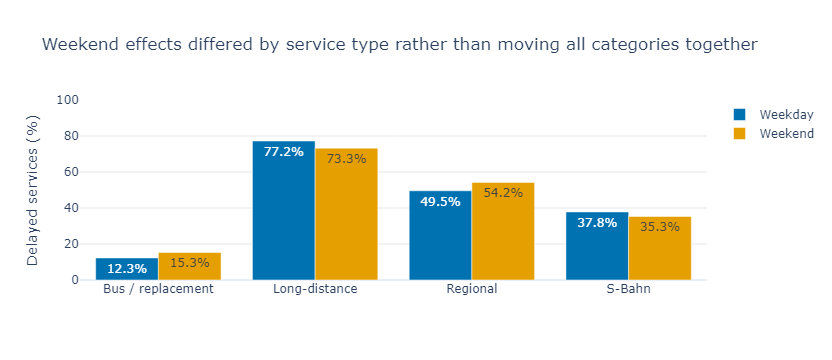

In [50]:
day_stats = (
    clean[
        clean["train_group"] != "Other"
    ]
    .groupby(
        ["day_type", "train_group"],
        as_index=False
    )
    .agg(
        total_services=("has_delay", "size"),
        delay_rate=("has_delay", "mean")
    )
)


day_stats["delay_rate_pct"] = (
    day_stats["delay_rate"] * 100
)


fig = px.bar(
    day_stats,
    x="train_group",
    y="delay_rate_pct",
    color="day_type",
    barmode="group",
    text=day_stats["delay_rate_pct"].map(
        lambda value: f"{value:.1f}%"
    ),
    color_discrete_map={
        "Weekday": CVD_BLUE,
        "Weekend": CVD_ORANGE
    },
    hover_data={
        "total_services": ":,",
        "delay_rate_pct": ":.1f"
    },
    title=(
        "Weekend effects differed by service type "
        "rather than moving all categories together"
    )
)

fig.update_layout(
    template="plotly_white",
    legend_title_text=""
)

fig.update_xaxes(
    title=""
)

fig.update_yaxes(
    title="Delayed services (%)",
    range=[0, 100],
    gridcolor="#E5E7EB"
)

fig.show()

### Answer

The weekend effect was not consistent across all service types. Long-distance
services had a slightly higher weekday delay rate, approximately **77.2%**
compared with **73.3%** on weekends.

Regional services moved in the opposite direction, increasing from
approximately **49.5% on weekdays** to **54.2% on weekends**. Bus/replacement
services also recorded a higher weekend rate, while the S-Bahn rate was
slightly lower.

This suggests that weekday versus weekend conditions affected service
categories differently.

## Question 6 — When a delayed service had usable real-time information, how severe was the delay for each train group?

### Why this matters

Delay rate measures how often a service is delayed, but it does not show how
long the delay lasts. Reliability should therefore consider both frequency and
severity.

### Method

Only records marked as delayed and containing an extractable actual time are
used. Their actual delay durations are compared using box plots.

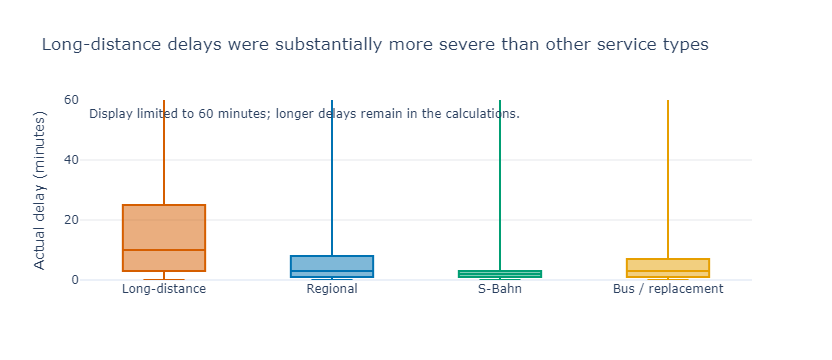

In [51]:
delayed_with_time = clean[
    (clean["has_delay"] == 1)
    & clean["actual_delay_minutes"].notna()
    & (clean["train_group"] != "Other")
].copy()


fig = px.box(
    delayed_with_time,
    x="train_group",
    y="actual_delay_minutes",
    color="train_group",
    category_orders={
        "train_group": group_order
    },
    color_discrete_map=group_palette,
    points=False,
    title=(
        "Long-distance delays were substantially "
        "more severe than other service types"
    )
)

fig.update_layout(
    template="plotly_white",
    showlegend=False
)

fig.update_xaxes(
    title=""
)

fig.update_yaxes(
    title="Actual delay (minutes)",
    range=[0, 60],
    gridcolor="#E5E7EB"
)

fig.add_annotation(
    x=0.01,
    y=0.98,
    xref="paper",
    yref="paper",
    text=(
        "Display limited to 60 minutes; longer delays "
        "remain in the calculations."
    ),
    showarrow=False,
    align="left"
)

fig.show()

### Answer

Long-distance services had a median actual delay of approximately
**10 minutes**, compared with approximately **3 minutes** for regional and
bus/replacement services and **2 minutes** for S-Bahn services.

The difference became larger in the upper part of the distributions.
Approximately 10% of long-distance delayed records exceeded **48 minutes**,
compared with around **17 minutes** for regional and **7 minutes** for S-Bahn
services.

Long-distance services therefore performed poorly in both delay frequency and
delay severity.

## Question 7 — Which stations experienced the longest typical and severe delays?

### Why this matters

Stations with similar delay rates may experience very different delay
durations. Comparing the median and 90th percentile distinguishes typical
delay severity from more extreme cases.

### Method

For each station, the median and 90th-percentile actual delay are calculated
using delayed records with usable real-time information. Stations with fewer
than 100 such records are excluded.

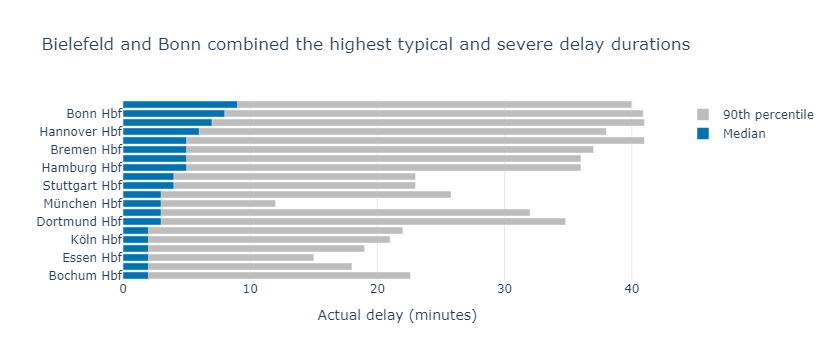

In [52]:
station_duration = (
    delayed_with_time.groupby(
        "station",
        as_index=False
    )
    .agg(
        delayed_records=(
            "actual_delay_minutes",
            "size"
        ),
        median_delay=(
            "actual_delay_minutes",
            "median"
        ),
        p90_delay=(
            "actual_delay_minutes",
            lambda values: values.quantile(0.90)
        )
    )
)


station_duration = station_duration[
    station_duration["delayed_records"] >= 100
].copy()


station_duration = station_duration.sort_values(
    "median_delay"
)


fig = go.Figure()


fig.add_trace(
    go.Bar(
        x=station_duration["p90_delay"],
        y=station_duration["station"],
        orientation="h",
        name="90th percentile",
        marker_color=CONTEXT_GREY,
        hovertemplate=(
            "%{y}<br>"
            "90th percentile: %{x:.1f} min"
            "<extra></extra>"
        )
    )
)


fig.add_trace(
    go.Bar(
        x=station_duration["median_delay"],
        y=station_duration["station"],
        orientation="h",
        name="Median",
        marker_color=CVD_BLUE,
        hovertemplate=(
            "%{y}<br>"
            "Median: %{x:.1f} min"
            "<extra></extra>"
        )
    )
)


fig.update_layout(
    barmode="overlay",
    template="plotly_white",
    title=(
        "Bielefeld and Bonn combined the highest "
        "typical and severe delay durations"
    ),
    xaxis_title="Actual delay (minutes)",
    yaxis_title="",
    legend_title_text=""
)

fig.update_xaxes(
    gridcolor="#E5E7EB"
)

fig.show()

### Answer

Bielefeld Hbf recorded the highest median actual delay at approximately
**9 minutes**, followed by Bonn Hbf at **8 minutes** and Münster (Westf) Hbf
at **7 minutes**.

Their more severe delays were also substantial. The 90th-percentile delay was
approximately **40 minutes** at Bielefeld and Bonn and approximately
**41 minutes** at Münster.

This differs from the delay-rate ranking. München had the highest delay rate,
but Bielefeld and Bonn experienced longer typical delay durations.

## Question 8 — Which sampled dates combined high delay rates with long average delays?

### Why this matters

A day may contain many delayed services but only short delays, while another
may contain fewer disruptions of greater severity. Comparing both measures
helps identify different forms of system-wide disruption.

### Method

For each sampled date, the delay rate, average actual delay and number of
services are calculated. Bubble size represents service volume.

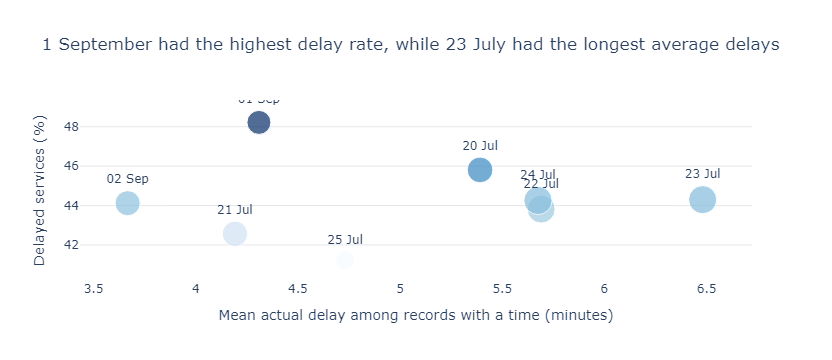

In [53]:
date_stats = (
    clean.groupby(
        "date",
        as_index=False
    )
    .agg(
        total_services=("has_delay", "size"),
        delay_rate=("has_delay", "mean"),
        mean_actual_delay=(
            "actual_delay_minutes",
            "mean"
        )
    )
)


date_stats["delay_rate_pct"] = (
    date_stats["delay_rate"] * 100
)


date_stats["date_label"] = (
    date_stats["date"].dt.strftime("%d %b")
)


fig = px.scatter(
    date_stats,
    x="mean_actual_delay",
    y="delay_rate_pct",
    size="total_services",
    text="date_label",
    color="delay_rate_pct",
    color_continuous_scale="Blues",
    hover_data={
        "total_services": ":,",
        "delay_rate_pct": ":.1f",
        "mean_actual_delay": ":.1f",
        "date_label": False
    },
    title=(
        "1 September had the highest delay rate, "
        "while 23 July had the longest average delays"
    )
)

fig.update_traces(
    textposition="top center"
)

fig.update_layout(
    template="plotly_white",
    coloraxis_showscale=False
)

fig.update_xaxes(
    title=(
        "Mean actual delay among records "
        "with a time (minutes)"
    ),
    showgrid=False
)

fig.update_yaxes(
    title="Delayed services (%)",
    gridcolor="#E5E7EB"
)

fig.show()

### Answer

The sampled dates did not have one single day that was worst on every measure.

**1 September** had the highest delay rate at approximately **48.2%**, while
**23 July** had the longest mean actual delay at approximately **6.5 minutes**.
The delay rate on 23 July was approximately **44.3%**.

This distinction shows why both frequency and duration are needed. A date with
the most delayed records proportionally was not necessarily the date with the
longest delays.

## Question 9 — Which commonly recorded disruption reasons were associated with the longest delays?

### Why this matters

The most frequently recorded cause is not necessarily the cause associated
with the most severe delays. Comparing reasons using median duration helps
identify high-impact disruptions.

### Method

Reasons are extracted from the German text following `Grund:`. Only reasons
with at least 50 records and a usable actual delay duration are included.
The twelve reasons with the highest median delay are displayed.

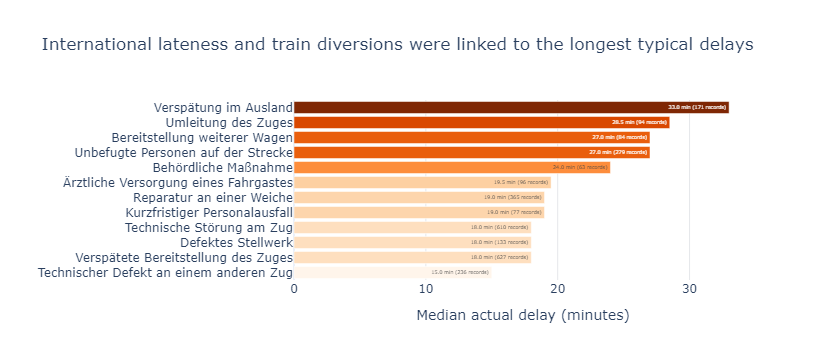

In [54]:
reason_stats = (
    clean[
        clean["delay_reason"].notna()
        & clean["actual_delay_minutes"].notna()
    ]
    .groupby(
        "delay_reason",
        as_index=False
    )
    .agg(
        records=("delay_reason", "size"),
        median_delay=(
            "actual_delay_minutes",
            "median"
        )
    )
)


reason_stats = reason_stats[
    reason_stats["records"] >= 50
].copy()


reason_top = (
    reason_stats
    .nlargest(12, "median_delay")
    .sort_values("median_delay")
)


reason_top["label"] = reason_top.apply(
    lambda row: (
        f'{row["median_delay"]:.1f} min '
        f'({int(row["records"])} records)'
    ),
    axis=1
)


fig = px.bar(
    reason_top,
    x="median_delay",
    y="delay_reason",
    orientation="h",
    text="label",
    color="median_delay",
    color_continuous_scale="Oranges",
    hover_data={
        "records": ":,",
        "median_delay": ":.1f"
    },
    title=(
        "International lateness and train diversions "
        "were linked to the longest typical delays"
    )
)

fig.update_layout(
    template="plotly_white",
    coloraxis_showscale=False
)

fig.update_xaxes(
    title="Median actual delay (minutes)",
    gridcolor="#E5E7EB"
)

fig.update_yaxes(
    title=""
)

fig.show()

### Answer

`Verspätung im Ausland`, meaning delay originating abroad, had the highest
median delay at approximately **33 minutes** among commonly recorded reasons.

`Umleitung des Zuges`, meaning train diversion, followed at approximately
**28.5 minutes**. Additional-carriage provision and unauthorised persons on
the railway both had median delays of approximately **27 minutes**.

These reasons were not necessarily the most frequent, but they were associated
with particularly severe delays when they occurred.

## Question 10 — At which stations were platform changes recorded most often, and how much delay accompanied them?

### Why this matters

Platform changes can create passenger inconvenience even when the train delay
is not especially long. Comparing their frequency and accompanying delay shows
where this operational issue was most significant.

### Method

The word `Gleiswechsel`, meaning platform change, is identified in the
real-time text. For each station, its recorded platform-change rate and median
actual delay during those records are calculated.

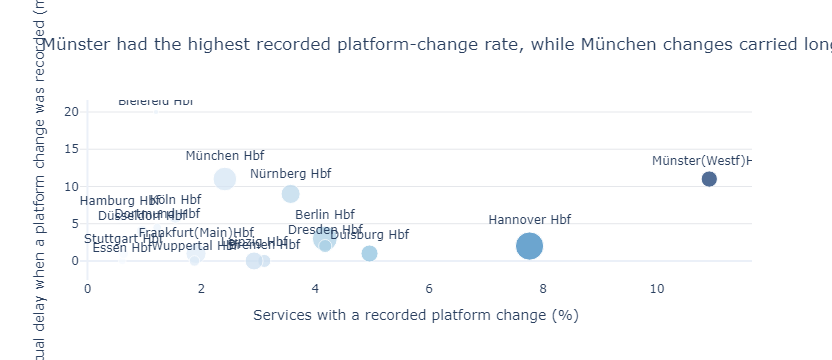

In [55]:
platform_stats = (
    clean.groupby(
        "station",
        as_index=False
    )
    .agg(
        total_services=("has_delay", "size"),
        platform_changes=("platform_change", "sum")
    )
)


platform_stats["platform_change_rate_pct"] = (
    platform_stats["platform_changes"]
    / platform_stats["total_services"]
    * 100
)


platform_delay = (
    clean[
        clean["platform_change"]
        & clean["actual_delay_minutes"].notna()
    ]
    .groupby(
        "station",
        as_index=False
    )
    .agg(
        median_delay_with_change=(
            "actual_delay_minutes",
            "median"
        ),
        changes_with_time=(
            "actual_delay_minutes",
            "size"
        )
    )
)


platform_stats = platform_stats.merge(
    platform_delay,
    on="station",
    how="left"
)


platform_stats = platform_stats[
    platform_stats["changes_with_time"] >= 10
].copy()


fig = px.scatter(
    platform_stats,
    x="platform_change_rate_pct",
    y="median_delay_with_change",
    size="platform_changes",
    text="station",
    color="platform_change_rate_pct",
    color_continuous_scale="Blues",
    hover_data={
        "total_services": ":,",
        "platform_changes": ":,",
        "changes_with_time": ":,",
        "platform_change_rate_pct": ":.1f",
        "median_delay_with_change": ":.1f"
    },
    title=(
        "Münster had the highest recorded platform-change "
        "rate, while München changes carried longer delays"
    )
)

fig.update_traces(
    textposition="top center"
)

fig.update_layout(
    template="plotly_white",
    coloraxis_showscale=False
)

fig.update_xaxes(
    title=(
        "Services with a recorded "
        "platform change (%)"
    ),
    showgrid=False
)

fig.update_yaxes(
    title=(
        "Median actual delay when a platform "
        "change was recorded (minutes)"
    ),
    gridcolor="#E5E7EB"
)

fig.show()

### Answer

Münster (Westf) Hbf had the highest recorded platform-change rate at
approximately **10.9%**, with a median accompanying delay of approximately
**11 minutes**.

Hannover had the second-highest platform-change rate at approximately **7.8%**,
but its median accompanying delay was only around **2 minutes**. München had a
lower recorded platform-change rate of approximately **2.4%**, but the median
delay associated with those changes was approximately **11 minutes**.

This shows that platform-change frequency and delay severity did not always
move together.

# 4. Overall Conclusions

The analysis produces four main conclusions.

1. **Long-distance services were the weakest-performing category.**  
   They had both the highest delay rate and the longest actual delay duration.

2. **Station performance varied substantially.**  
   München had the highest recorded delay rate, while Bielefeld and Bonn
   experienced longer typical delays.

3. **Delay frequency and delay severity were different dimensions.**  
   The date or station with the highest delay rate was not always the one with
   the longest average or median delay.

4. **Operational causes had unequal effects.**  
   Delays originating abroad, train diversions and unauthorised persons on the
   railway were associated with particularly long typical delays.

Together, the results show that Deutsche Bahn reliability cannot be understood
using one measure alone. Train category, station, time, delay duration and
recorded operational reason must be considered together.

# 5. Limitations

This analysis has several important limitations.

- The dataset covers only eight sampled dates rather than a complete year.
- The results therefore describe the available sample and should not be treated
  as a full long-term assessment of Deutsche Bahn performance.
- Actual delay duration could only be calculated when a usable time appeared
  in the real-time information field.
- The `real_time_due_to_delay` field contains mixed time and German text, and
  some records have missing information.
- Train groups were derived from service-code prefixes and may simplify some
  operator-specific categories.
- The `has_delay` field is used as supplied by the dataset publisher.
- The analysis identifies associations and patterns but does not prove that
  one factor caused another.